# Reto del día — Análisis de texto e imágenes con Gemini

Notebook de análisis de resultados de los dos retos:

| Reto | Tareas | Datos |
| --- | --- | --- |
| **1. Texto** | detección de idioma · NER · sentimiento · resumen | 10 textos (noticias, reseñas, emails) en 6 idiomas |
| **2. Visión** | OCR · descripción visual · clasificación de escena · detección de objetos | 5 imágenes de test |

Todos los prompts piden **JSON estructurado** al modelo y las predicciones se
comparan contra un *ground truth* anotado a mano en `data/`.

> **Estado:** las ejecuciones contra la API quedaron bloqueadas con
> `403 PERMISSION_DENIED`. Este notebook muestra las métricas disponibles y, si no
> las hay, explica el error y cómo regenerarlas. Ver `docs/API_ERROR.md`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS = ROOT / "results"
DATA = ROOT / "data"
IMAGES = ROOT / "images"


def load(path: Path):
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None


text_res = load(RESULTS / "text_results.json")
vision_res = load(RESULTS / "vision_results.json")
metricas = load(RESULTS / "metricas.json")
informe = (RESULTS / "informe.md")

errores = [r.get("error") for r in (text_res, vision_res) if isinstance(r, dict) and r.get("error")]

print(f"results/text_results.json   : {'OK' if text_res else 'AUSENTE'}")
print(f"results/vision_results.json : {'OK' if vision_res else 'AUSENTE'}")
print(f"results/metricas.json       : {'OK' if metricas else 'AUSENTE'}")
if errores:
    print("\n!! La API devolvio errores -> las metricas estaran incompletas.")

results/text_results.json   : OK
results/vision_results.json : OK
results/metricas.json       : OK

!! La API devolvio errores -> las metricas estaran incompletas.


## 1. Conjunto de datos de prueba

### 1.1 Diez textos: noticias, reseñas y emails en 6 idiomas

In [2]:
textos = load(DATA / "textos.json")["textos"]

rows = "| ID | Tipo | Idioma | Extracto |\n| --- | --- | --- | --- |"
for t in textos:
    extracto = t["texto"][:90].replace("\n", " ") + "..."
    rows += f"\n| {t['id']} | {t['tipo']} | {t['idioma_esperado']} | {extracto} |"
display(Markdown(rows))

| ID | Tipo | Idioma | Extracto |
| --- | --- | --- | --- |
| t01 | noticia | es | El Real Madrid conquistó el Santiago Bernabéu con una victoria por 3-1 frente al FC Barcel... |
| t02 | noticia | en | NASA announced on Tuesday that the Artemis III mission will launch from Kennedy Space Cent... |
| t03 | resena | es | Compré auriculares inalámbricos NovaSound Pro por 129 euros en marzo y fue una decepción t... |
| t04 | resena | en | I have been using the Focusly task manager for six months and it has completely changed ho... |
| t05 | email | es | Asunto: Reunión de planificación trimestral  Hola Marta,  Te escribo para confirmar la reu... |
| t06 | email | en | Subject: Invoice INV-2291 overdue  Hi Daniel,  Our records show that invoice INV-2291 for ... |
| t07 | noticia | fr | Le gouvernement français a annoncé jeudi que le budget de la SNCF sera porté à 25 milliard... |
| t08 | resena | pt | O restaurante Cantina do Zé, no Porto, foi uma experiência medíocre. A espera de 50 minuto... |
| t09 | email | de | Betreff: Projektstatus Alpha - Meilenstein 3  Sehr geehrte Frau Schneider,  hiermit bestät... |
| t10 | noticia | it | Milano sta preparando il nuovo piano urbano per la mobilità: la Giunta guidata dal sindaco... |

### 1.2 Cinco imágenes de test (generadas con Pillow, ground truth exacto)

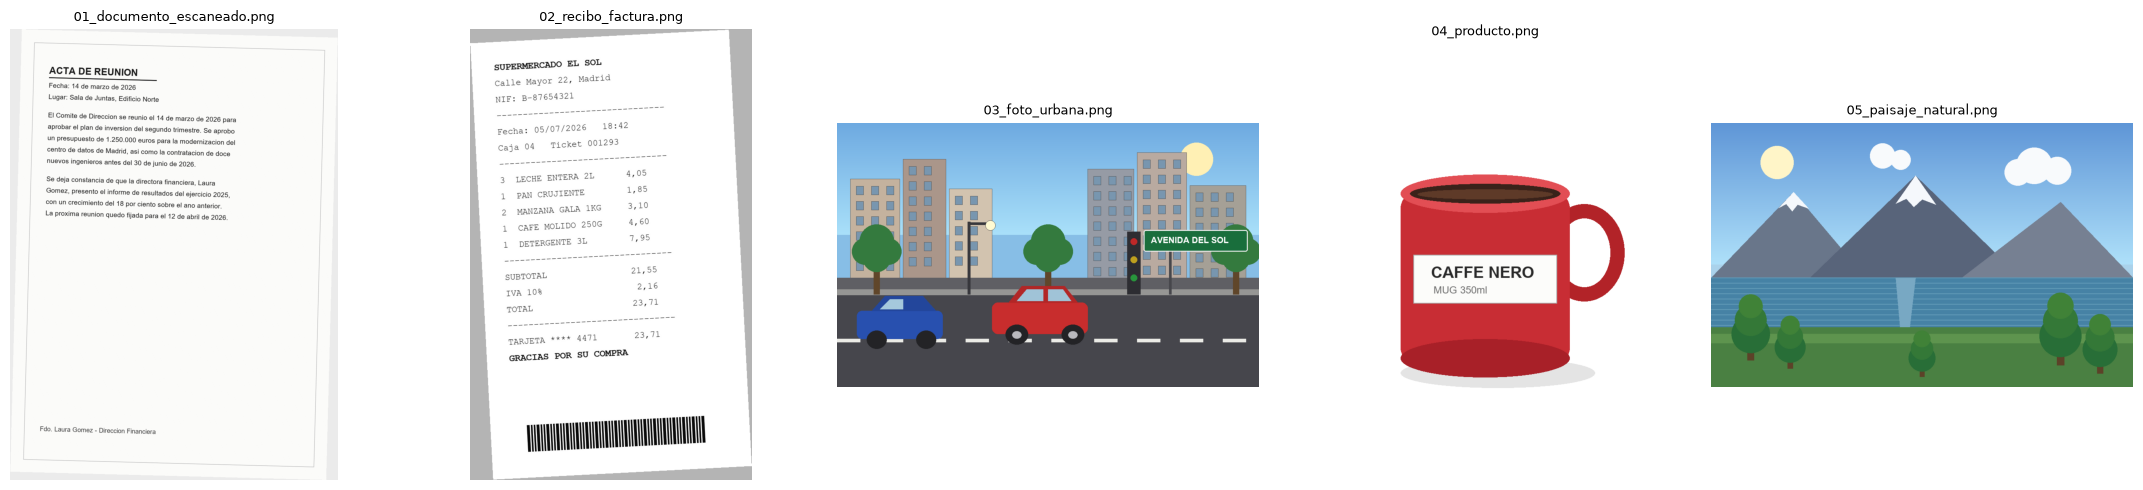

In [3]:
from PIL import Image

orden = sorted(IMAGES.glob("*.png"))
fig, axes = plt.subplots(1, len(orden), figsize=(22, 5))
if len(orden) == 1:
    axes = [axes]
for ax, path in zip(axes, orden):
    ax.imshow(Image.open(path))
    ax.set_title(path.name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Reto 1 — Análisis de texto

Métricas agregadas sobre los 10 textos.

In [4]:
def tabla_metricas(bloque: dict, columnas: tuple[str, str, str]) -> None:
    cab = "| " + " | ".join(columnas) + " |"
    sep = "| " + " | ".join("---" for _ in columnas) + " |"
    filas = []
    for etiqueta, valor, n in bloque:
        filas.append(f"| {etiqueta} | {valor} | {n} |")
    display(Markdown("\n".join([cab, sep] + filas)))


def fmt(v, pct=False):
    if v is None:
        return "n/d"
    return f"{v * 100:.1f}%" if pct else str(v)


if metricas and metricas.get("texto"):
    t = metricas["texto"]["resumen"]
    tabla_metricas(
        [
            ("Detección de idioma (accuracy)", fmt(t["idioma"]["accuracy"], True), t["idioma"]["evaluados"]),
            ("Entidades (precision)", fmt(t["entidades"]["precision"], True), t["entidades"]["evaluados"]),
            ("Entidades (recall)", fmt(t["entidades"]["recall"], True), t["entidades"]["evaluados"]),
            ("Entidades (F1)", fmt(t["entidades"]["f1"], True), t["entidades"]["evaluados"]),
            ("Sentimiento (accuracy)", fmt(t["sentimiento"]["accuracy"], True), t["sentimiento"]["evaluados"]),
            ("Sentimiento (MAE score)", fmt(t["sentimiento"]["mae_score"]), t["sentimiento"]["evaluados"]),
            ("Resumen (ROUGE-L F1)", fmt(t["resumen"]["rougeL_f1_medio"]), t["resumen"]["evaluados"]),
            ("Resumen (<= 40 palabras)", fmt(t["resumen"]["dentro_40_palabras"], True), t["resumen"]["evaluados"]),
        ],
        ("Métrica", "Valor", "Evaluados"),
    )
else:
    display(Markdown("_No hay `results/metricas.json` con datos de texto._"))

| Métrica | Valor | Evaluados |
| --- | --- | --- |
| Detección de idioma (accuracy) | n/d | 0 |
| Entidades (precision) | 0.0% | 0 |
| Entidades (recall) | 0.0% | 0 |
| Entidades (F1) | 0.0% | 0 |
| Sentimiento (accuracy) | n/d | 0 |
| Sentimiento (MAE score) | n/d | 0 |
| Resumen (ROUGE-L F1) | n/d | 0 |
| Resumen (<= 40 palabras) | n/d | 0 |

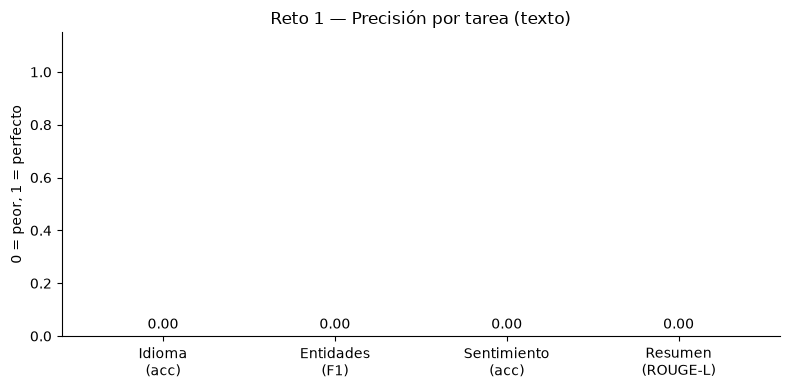

In [5]:
if metricas and metricas.get("texto"):
    t = metricas["texto"]["resumen"]
    etiquetas = ["Idioma\n(acc)", "Entidades\n(F1)", "Sentimiento\n(acc)", "Resumen\n(ROUGE-L)"]
    valores = [
        t["idioma"]["accuracy"],
        t["entidades"]["f1"],
        t["sentimiento"]["accuracy"],
        t["resumen"]["rougeL_f1_medio"],
    ]
    valores = [v if v is not None else 0 for v in valores]

    fig, ax = plt.subplots(figsize=(8, 4))
    barras = ax.bar(etiquetas, valores, color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
    ax.bar_label(barras, fmt="%.2f", padding=3, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title("Reto 1 — Precisión por tarea (texto)")
    ax.set_ylabel("0 = peor, 1 = perfecto")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

### Detalle registro a registro

In [6]:
if metricas and metricas.get("texto"):
    filas = "| ID | Tipo | Idioma pred. | OK | Entidades | Sentimiento pred. | OK | ROUGE-L |\n"
    filas += "| --- | --- | --- | --- | --- | --- | --- | --- |"
    for f in metricas["texto"]["detalle"]:
        ent = f.get("entidades_aciertos")
        ent_txt = f"{ent}/{len(f.get('entidades_gt', []))}" if ent is not None else "-"
        filas += (
            f"\n| {f['id']} | {f['tipo']} | {f.get('idioma_pred', '-')} "
            f"| {'✅' if f.get('idioma_ok') else '❌' if 'idioma_ok' in f else '-'} "
            f"| {ent_txt} | {f.get('sentimiento_pred', '-')} "
            f"| {'✅' if f.get('sentimiento_ok') else '❌' if 'sentimiento_ok' in f else '-'} "
            f"| {f.get('resumen_rougeL_f1', '-')} |"
        )
    display(Markdown(filas))
else:
    display(Markdown("_Sin detalle de texto._"))

| ID | Tipo | Idioma pred. | OK | Entidades | Sentimiento pred. | OK | ROUGE-L |
| --- | --- | --- | --- | --- | --- | --- | --- |
| t01 | noticia | - | - | - | - | - | - |

## 3. Reto 2 — Análisis de imágenes

OCR, descripción visual, clasificación de escena y detección de objetos.

In [7]:
if metricas and metricas.get("vision"):
    v = metricas["vision"]["resumen"]
    tabla_metricas(
        [
            ("OCR (similitud de caracteres)", fmt(v["ocr"]["similitud_media"]), v["ocr"]["evaluadas"]),
            ("Descripción (keyword recall)", fmt(v["descripcion"]["keyword_recall_medio"], True), v["descripcion"]["evaluadas"]),
            ("Escena (accuracy)", fmt(v["escena"]["accuracy"], True), v["escena"]["evaluadas"]),
            ("Objetos (precision)", fmt(v["objetos"]["precision"], True), v["objetos"]["evaluados"]),
            ("Objetos (recall)", fmt(v["objetos"]["recall"], True), v["objetos"]["evaluados"]),
            ("Objetos (F1)", fmt(v["objetos"]["f1"], True), v["objetos"]["evaluados"]),
        ],
        ("Métrica", "Valor", "Evaluadas"),
    )
else:
    display(Markdown("_No hay `results/metricas.json` con datos de visión._"))

| Métrica | Valor | Evaluadas |
| --- | --- | --- |
| OCR (similitud de caracteres) | n/d | 0 |
| Descripción (keyword recall) | n/d | 0 |
| Escena (accuracy) | n/d | 0 |
| Objetos (precision) | 0.0% | 0 |
| Objetos (recall) | 0.0% | 0 |
| Objetos (F1) | 0.0% | 0 |

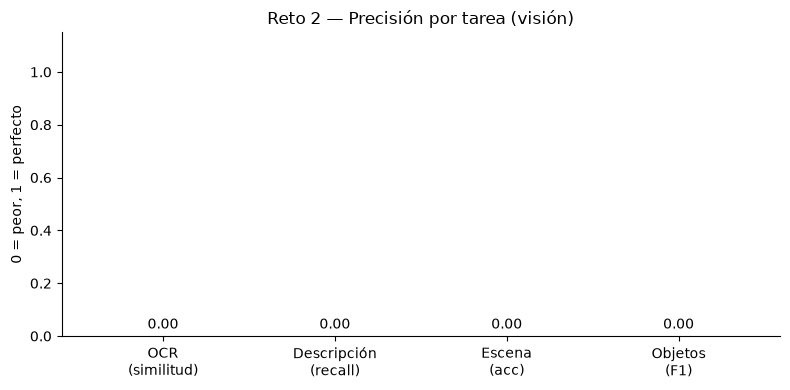

In [8]:
if metricas and metricas.get("vision"):
    v = metricas["vision"]["resumen"]
    etiquetas = ["OCR\n(similitud)", "Descripción\n(recall)", "Escena\n(acc)", "Objetos\n(F1)"]
    valores = [
        v["ocr"]["similitud_media"],
        v["descripcion"]["keyword_recall_medio"],
        v["escena"]["accuracy"],
        v["objetos"]["f1"],
    ]
    valores = [x if x is not None else 0 for x in valores]

    fig, ax = plt.subplots(figsize=(8, 4))
    barras = ax.bar(etiquetas, valores, color=["#4C78A8", "#72B7B2", "#54A24B", "#E45756"])
    ax.bar_label(barras, fmt="%.2f", padding=3, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title("Reto 2 — Precisión por tarea (visión)")
    ax.set_ylabel("0 = peor, 1 = perfecto")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

### Detalle por imagen (predicción vs. ground truth)

In [9]:
if metricas and metricas.get("vision"):
    filas = "| Imagen | Tarea | OCR sim. | Descr. recall | Escena pred. | Escena OK | Objetos |\n"
    filas += "| --- | --- | --- | --- | --- | --- | --- |"
    for f in metricas["vision"]["detalle"]:
        ent = f.get("objetos_aciertos")
        ent_txt = f"{ent}/{len(f.get('objetos_gt', []))}" if ent is not None else "-"
        filas += (
            f"\n| {f['archivo']} | {f['tipo_tarea']} | {f.get('ocr_similitud', '-')} "
            f"| {f.get('descripcion_keyword_recall', '-')} | {f.get('escena_pred', '-')} "
            f"| {'✅' if f.get('escena_ok') else '❌' if 'escena_ok' in f else '-'} | {ent_txt} |"
        )
    display(Markdown(filas))
else:
    display(Markdown("_Sin detalle de visión._"))

| Imagen | Tarea | OCR sim. | Descr. recall | Escena pred. | Escena OK | Objetos |
| --- | --- | --- | --- | --- | --- | --- |
| 01_documento_escaneado.png | ocr | - | - | - | - | - |

## 4. Comparativa: texto vs. visión por tipo de tarea

La tabla que pide el reto: qué tipo de tarea resuelve mejor cada modelo/dominio.

| Dominio | Tarea | Resultado |
| --- | --- | --- |
| TEXTO | Clasificación (idioma) | n/d |
| TEXTO | Extracción (entidades F1) | 0.0 |
| TEXTO | Clasificación (sentimiento) | n/d |
| TEXTO | Generación (resumen) | n/d |
| VISIÓN | OCR (documento) | n/d |
| VISIÓN | Descripción visual | n/d |
| VISIÓN | Clasificación de escena | n/d |
| VISIÓN | Detección de objetos | 0.0 |

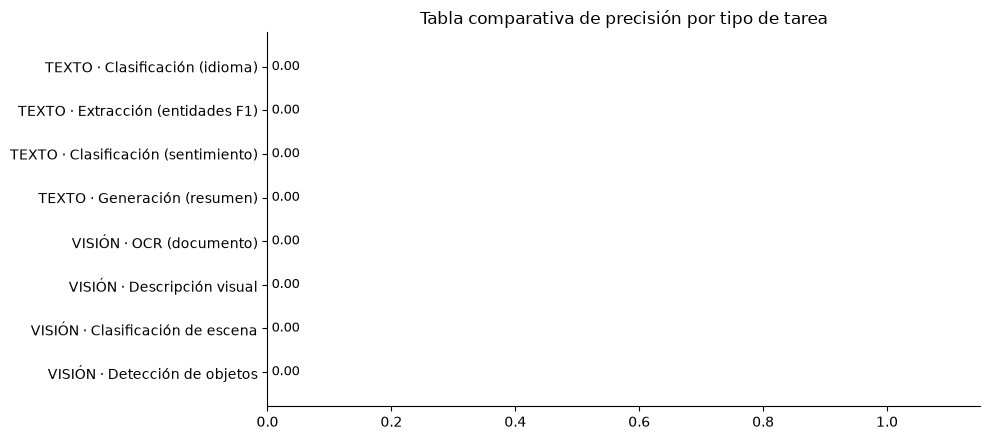

In [10]:
comparativa = []
if metricas and metricas.get("texto"):
    t = metricas["texto"]["resumen"]
    comparativa += [
        ("TEXTO", "Clasificación (idioma)", t["idioma"]["accuracy"]),
        ("TEXTO", "Extracción (entidades F1)", t["entidades"]["f1"]),
        ("TEXTO", "Clasificación (sentimiento)", t["sentimiento"]["accuracy"]),
        ("TEXTO", "Generación (resumen)", t["resumen"]["rougeL_f1_medio"]),
    ]
if metricas and metricas.get("vision"):
    v = metricas["vision"]["resumen"]
    comparativa += [
        ("VISIÓN", "OCR (documento)", v["ocr"]["similitud_media"]),
        ("VISIÓN", "Descripción visual", v["descripcion"]["keyword_recall_medio"]),
        ("VISIÓN", "Clasificación de escena", v["escena"]["accuracy"]),
        ("VISIÓN", "Detección de objetos", v["objetos"]["f1"]),
    ]

if comparativa:
    filas = "| Dominio | Tarea | Resultado |\n| --- | --- | --- |"
    for dom, tarea, val in comparativa:
        filas += f"\n| {dom} | {tarea} | {fmt(val, pct=False)} |"
    display(Markdown(filas))

    fig, ax = plt.subplots(figsize=(10, 4.5))
    colores = ["#4C78A8" if d == "TEXTO" else "#F58518" for d, _, _ in comparativa]
    barras = ax.barh([f"{d} · {t}" for d, t, _ in comparativa],
                     [v if v is not None else 0 for _, _, v in comparativa],
                     color=colores)
    ax.bar_label(barras, fmt="%.2f", padding=3, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.15)
    ax.set_title("Tabla comparativa de precisión por tipo de tarea")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_Sin métricas disponibles para comparar._"))

## 5. Conclusiones y estado de la ejecución

In [11]:
print("=" * 78)
if errores:
    print("EJECUCION INCOMPLETA - la API de Gemini no devolvio resultados reales")
    print("=" * 78)
    for e in errores:
        print(f"  tipo   : {e.get('tipo')}")
        print(f"  mensaje: {e.get('mensaje')}")
        print("-" * 78)
    print("")
    print("Para obtener las metricas reales:")
    print("  1. Abre .env y pega una GEMINI_API_KEY valida (proyecto con acceso habilitado).")
    print("  2. Ejecuta en la terminal:")
    print("        python -m src.text_analysis")
    print("        python -m src.vision_analysis")
    print("        python -m src.evaluation")
    print("  3. Vuelve a esta celda -> Run All.")
    print("  Detalle completo del error: docs/API_ERROR.md")
else:
    t = (metricas or {}).get("texto", {}).get("resumen")
    v = (metricas or {}).get("vision", {}).get("resumen")
    if t:
        print(f"Texto   - idioma={t['idioma']['accuracy']}  sentimiento={t['sentimiento']['accuracy']}  "
              f"entidades F1={t['entidades']['f1']}  resumen ROUGE-L={t['resumen']['rougeL_f1_medio']}")
    if v:
        print(f"Vision  - escena={v['escena']['accuracy']}  objetos F1={v['objetos']['f1']}  "
              f"OCR={v['ocr']['similitud_media']}  descripcion={v['descripcion']['keyword_recall_medio']}")
    print("=" * 78)

EJECUCION INCOMPLETA - la API de Gemini no devolvio resultados reales
  tipo   : ApiError
  mensaje: 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'Your project has been denied access. Please contact support.', 'status': 'PERMISSION_DENIED'}}
------------------------------------------------------------------------------
  tipo   : ApiError
  mensaje: 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'Your project has been denied access. Please contact support.', 'status': 'PERMISSION_DENIED'}}
------------------------------------------------------------------------------

Para obtener las metricas reales:
  1. Abre .env y pega una GEMINI_API_KEY valida (proyecto con acceso habilitado).
  2. Ejecuta en la terminal:
        python -m src.text_analysis
        python -m src.vision_analysis
        python -m src.evaluation
  3. Vuelve a esta celda -> Run All.
  Detalle completo del error: docs/API_ERROR.md
